Graph Neural Network (GNN) — Node Classification on Citation Network

In [1]:
%pip install torch_geometric

   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ----------------------- ---------------- 0.8/1.3 MB 3.6 MB/s eta 0:00:01
   ---------------------------------------- 1.3/1.3 MB 4.7 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [3]:
# CELL 2 — Load dataset (Cora citation network — classic GNN benchmark)
from torch_geometric.datasets import Planetoid
import torch_geometric.transforms as T

dataset = Planetoid(root="./data/Cora", name="Cora", transform=T.NormalizeFeatures())
data = dataset[0].to(device)

print(f"Nodes: {data.num_nodes} | Edges: {data.num_edges}")
print(f"Features per node: {dataset.num_node_features} | Classes: {dataset.num_classes}")
print(f"Train nodes: {data.train_mask.sum().item()} | Test nodes: {data.test_mask.sum().item()}")

c:\Users\chari\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Processing...


Nodes: 2708 | Edges: 10556
Features per node: 1433 | Classes: 7
Train nodes: 140 | Test nodes: 1000


Done!


In [4]:
# CELL 3 — Understand the task
# Each node = a research paper. Each edge = a citation link.
# Node features = bag-of-words vector of the paper's text.
# Goal: predict the paper's subject category using both its own features
# AND the features of papers it cites/is cited by (message passing).

print("Example node feature vector (first 20 dims):")
print(data.x[0][:20])
print("\nExample label:", data.y[0].item())
print("Class names (Cora):", ["Case_Based", "Genetic_Algorithms", "Neural_Networks",
                                "Probabilistic_Methods", "Reinforcement_Learning",
                                "Rule_Learning", "Theory"])

Example node feature vector (first 20 dims):
tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.1111])

Example label: 3
Class names (Cora): ['Case_Based', 'Genetic_Algorithms', 'Neural_Networks', 'Probabilistic_Methods', 'Reinforcement_Learning', 'Rule_Learning', 'Theory']


In [5]:
# CELL 4 — Model definition (Graph Convolutional Network)
from torch_geometric.nn import GCNConv

class GCN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)  # aggregates neighbor features
        self.conv2 = GCNConv(hidden_dim, output_dim)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)   # message passing: mix each node with its neighbors
        x = F.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index)   # raw logits per class
        return x

model = GCN(input_dim=dataset.num_node_features, hidden_dim=16, output_dim=dataset.num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
print(model)

GCN(
  (conv1): GCNConv(1433, 16)
  (conv2): GCNConv(16, 7)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [6]:
# CELL 5 — Training loop
epochs = 200
history = {"loss": [], "train_acc": [], "val_acc": []}

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        preds = out.argmax(dim=1)
        train_acc = (preds[data.train_mask] == data.y[data.train_mask]).float().mean().item()
        val_acc = (preds[data.val_mask] == data.y[data.val_mask]).float().mean().item()

    history["loss"].append(loss.item())
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs} — Loss: {loss.item():.4f} | Train Acc: {train_acc*100:.2f}% | Val Acc: {val_acc*100:.2f}%")

Epoch 20/200 — Loss: 1.7174 | Train Acc: 73.57% | Val Acc: 42.20%
Epoch 40/200 — Loss: 1.3281 | Train Acc: 87.86% | Val Acc: 59.60%
Epoch 60/200 — Loss: 0.9540 | Train Acc: 92.14% | Val Acc: 62.60%
Epoch 80/200 — Loss: 0.6925 | Train Acc: 91.43% | Val Acc: 66.60%
Epoch 100/200 — Loss: 0.5591 | Train Acc: 95.71% | Val Acc: 67.20%
Epoch 120/200 — Loss: 0.4700 | Train Acc: 93.57% | Val Acc: 67.40%
Epoch 140/200 — Loss: 0.4071 | Train Acc: 97.86% | Val Acc: 67.80%
Epoch 160/200 — Loss: 0.3849 | Train Acc: 96.43% | Val Acc: 74.80%
Epoch 180/200 — Loss: 0.3435 | Train Acc: 96.43% | Val Acc: 70.20%
Epoch 200/200 — Loss: 0.3223 | Train Acc: 97.86% | Val Acc: 73.00%


In [7]:
# CELL 6 — Evaluation on test set
model.eval()
with torch.no_grad():
    out = model(data.x, data.edge_index)
    preds = out.argmax(dim=1)
    test_acc = (preds[data.test_mask] == data.y[data.test_mask]).float().mean().item()

print(f"Test Accuracy: {test_acc*100:.2f}%")

Test Accuracy: 79.90%


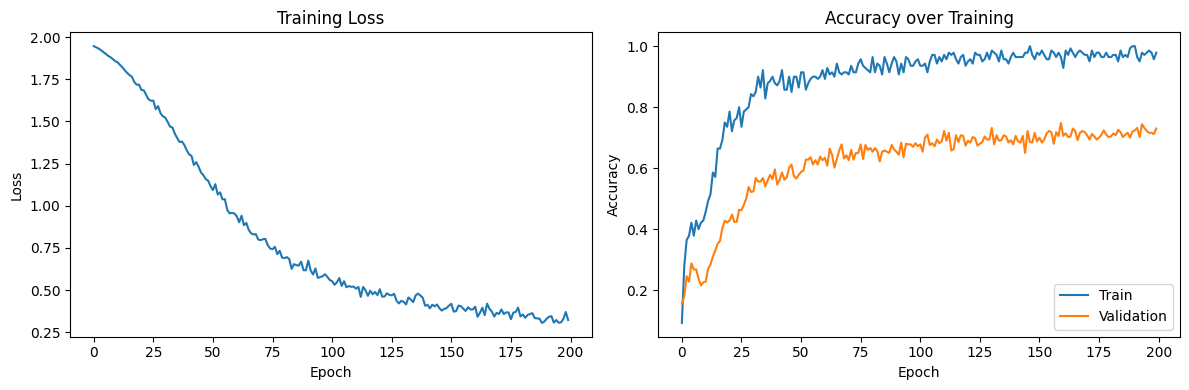

In [8]:
# CELL 7 — Plot training curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], label="Train")
plt.plot(history["val_acc"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy over Training")
plt.legend()

plt.tight_layout()
plt.show()

In [9]:
# CELL 8 — Ablation: compare against an MLP that ignores graph structure
# This demonstrates WHY message passing (the graph structure) actually helps
class MLPBaseline(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x, edge_index=None):  # edge_index ignored — no graph awareness
        return self.net(x)

mlp_model = MLPBaseline(dataset.num_node_features, 16, dataset.num_classes).to(device)
mlp_optimizer = torch.optim.Adam(mlp_model.parameters(), lr=0.01, weight_decay=5e-4)

for epoch in range(200):
    mlp_model.train()
    mlp_optimizer.zero_grad()
    out = mlp_model(data.x)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    mlp_optimizer.step()

mlp_model.eval()
with torch.no_grad():
    out = mlp_model(data.x)
    mlp_test_acc = (out.argmax(dim=1)[data.test_mask] == data.y[data.test_mask]).float().mean().item()

print(f"GCN (uses graph structure) Test Accuracy: {test_acc*100:.2f}%")
print(f"MLP (ignores graph structure) Test Accuracy: {mlp_test_acc*100:.2f}%")
print("\nThe gap shows the value of message passing over citation links.")

GCN (uses graph structure) Test Accuracy: 79.90%
MLP (ignores graph structure) Test Accuracy: 56.10%

The gap shows the value of message passing over citation links.
